\newpage

# Introduction

Avant de parler théorie, on part d'un exemple concret. Soit un annuaire téléphonique papier trié par ordre alphabétique, contenant 1000 noms et on cherche un nom précis. Deux algorithmes sont possibles :

- ***Recherche séquentielle***

On part de la première page, et on regarde nom par nom jusqu'à trouver celui qu'on cherche (ou jusqu'à la fin si le nom n'existe pas).

In [ ]:
def recherche_séquentielle(annuaire, nom):
    n = len(annuaire)
    for i in range(n):
        if annuaire[i] == nom:
            return i
    return -1 # non trouvé

Dans le meilleur des cas (le nom est en première position) on aura besoin d'une seule comparaison. Mais on s'intéresse au pire des cas (le nom est en dernière position, ou n'existe pas), dans ce cas on doit examiner tous les 1000 noms de l'annuaire.

- ***Recherche binaire (dichotomie)***

Puisque l'annuaire est trié, on peut faire mieux : on ouvre le livre au milieu. Si le nom cherché vient avant alphabétiquement, on jette toute la seconde moitié et on recommence sur la première moitié — et inversement. 

In [ ]:
def recherche_binaire(annuaire, nom):
    gauche, droite = 0, len(annuaire) - 1
    while gauche <= droite:
        milieu = (gauche + droite) // 2
        if annuaire[milieu] == nom:
            return milieu
        elif annuaire[milieu] < nom:
            gauche = milieu + 1
        else:
            droite = milieu - 1
    return -1 # non trouvé

À chaque étape, on élimine la moitié des possibilités restantes.

Pour bien saisir la différence on peut comparer graphiquement le nombre de comparaisons effectuées, au pire des cas, des deux algorithmes pour différentes tailles de l'annuaire :

n=      10 | séquentielle:       10 | dichotomique:   3
n=     100 | séquentielle:      100 | dichotomique:   6
n=    1000 | séquentielle:     1000 | dichotomique:   9
n=   10000 | séquentielle:    10000 | dichotomique:  13
n=  100000 | séquentielle:   100000 | dichotomique:  16
n= 1000000 | séquentielle:  1000000 | dichotomique:  19


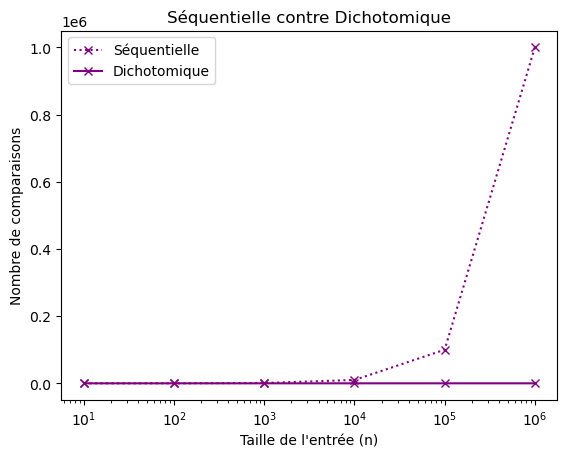

In [1]:
import matplotlib.pyplot as plt

def recherche_séquentielle(tab, x):
    c = 0
    for i in range(len(tab)):
        c += 1
        if tab[i] == x:
            return c
    return c

def recherche_dichotomique(tab, x):
    c = 0
    gauche, droite = 0, len(tab) - 1
    while gauche <= droite:
        c += 1
        milieu = (gauche + droite) // 2
        if tab[milieu] == x:
            return c
        elif tab[milieu] < x:
            gauche = milieu + 1
        else:
            droite = milieu - 1
    return c

 
# Expérience : pire cas (élément absent) pour differentes tailles
tailles = [10, 100, 1000, 10000, 100000, 1000000]
c1 = []
c2 = []
for n in tailles:
    tab = list(range(n))       # liste triée 0, 1, ..., n-1
    x = -1                     # valeur absente -> force le pire cas
    c1.append(recherche_séquentielle(tab, x))
    c2.append(recherche_dichotomique(tab, x))
    
# Affichage des résultats
for n, s, d in zip(tailles, c1, c2):
    print(f"n={n:>8} | séquentielle: {s:>8} | dichotomique: {d:>3}")
    
# Trace graphique
plt.plot(tailles, c1, marker='x', color='purple', linestyle=':', label='Séquentielle')
plt.plot(tailles, c2, marker='x', color='purple', label='Dichotomique')
plt.xscale('log')
plt.xlabel("Taille de l'entrée (n)")
plt.ylabel('Nombre de comparaisons')
plt.legend()
plt.title('Séquentielle contre Dichotomique')
plt.show()

On remarque facilement que la recherche séquentielle a une vitesse de croissance plus rapide que celle de la recherche dichotomique. Pour un million de noms, la recherche séquentielle peut demander un million de comparaisons, alors que la recherche binaire en demande à peine 19. C'est précisément ce genre d'écart que la théorie de la complexité permet de prévoir et de comparer, sans avoir à tester le programme sur des exemples géants.

Ce n'est pas la rapidité d'un ordinateur qui compte ici, mais la stratégie de l'algorithme. Un ordinateur 1000 fois plus rapide ne sauvera pas la recherche séquentielle face à la recherche binaire sur de très grands tableaux de données.

# Qu'est-ce que la complexité ?

On distingue deux types de complexité :

- **Complexité temporelle** (mesure du temps) : La complexité temporelle d'un algorithme est une fonction, notée $T(n)$, qui donne le nombre d'opérations élémentaires exécutées par l'algorithme, en fonction de la taille $n$ des données en entrée.


- **Complexité spatiale** (mesure de l'espace) : La complexité spatiale d'un algorithme est une fonction $S(n)$ (ou parfois notée $M(n)$) qui donne la quantité de mémoire supplémentaire (à l'exception des données d'entrée) utilisée par l'algorithme, en fonction de la taille $n$ des données en entrée.

Les deux mesures sont théoriques et sont faites indépendamment de n'importe quelle machine réelle.

# Cas d'études

Pour une taille d'entrée $n$, on note $E_n$ l'ensemble de toutes les entrées possibles de taille $n$, et pour une entrée $x \in E_n$ on note $T(x)$ le temps d'exécution de l'algorithme sur cette entrée précise. On distingue trois cas :

- ***Pire cas*** : 

$$T_{\text{pire}}(n) = \max_{x \in E_n} T(x)$$

- ***Cas moyen*** :

$$T_{\text{moyen}}(n) = \sum_{x \in E_n} p(x)\, T(x)$$

où $p(x)$ est la probabilité de l'entrée $x$.


- ***Meilleur cas*** :

$$T_{\text{meilleur}}(n) = \min_{x \in E_n} T(x)$$

*Généralement, on s'intéresse au premier cas, car il garantit que l'algorithme ne fera jamias pire que ça.*


# Les notations asymptotiques

Pour décrire le comportement d'un algorithme quand $n$ tend vers l'infini on utilise trois notations :
  
$$
\begin{array}{|c|c|c|}
\hline
\textbf{Notation} & \textbf{Définition formelle} & \textbf{Explication} \\
\hline
O(f(n)) & \exists c>0, n_0,\ \forall n \ge n_0,\ T(n) \le c\,f(n) & T \> ne \> grandit \> pas \> plus \> rapidement \> que \> f \\
\hline
\Omega(f(n)) & \exists c>0, n_0,\ \forall n \ge n_0,\ c\,f(n) \le T(n) & T \> ne \> grandit \> pas \> plus \> lentement \> que \> f\\
\hline
\Theta(f(n)) & T(n) = O(f(n)) et T(n) = \Omega(f(n)) & T \> et \> f \> ont \> le \> m\hat{e}me \> ordre \> de \> grandeur\\
\hline
\end{array}
$$

# Les ordres de grandeur classiques

(de la plus lente à la plus rapide)

$$
\begin{array}{|c|c|c|}
\hline
\textbf{Notation} & \textbf{Nom}  \\
\hline
O(1) & \text{Constant} \\
\hline
O(\log n) & \text{Logarithmique}\\
\hline
O(n) & \text{Linéaire}  \\
\hline
O(n \log n) & \text{Quasi-linéaire}  \\
\hline
O(n^2) & \text{Quadratique} \\
\hline
O(n^3) & \text{Cubique}  \\
\hline
O(2^n) & \text{Exponentiel} \\
\hline
O(n!) & \text{Factoriel}  \\
\hline
\end{array}
$$

et graphiquement :

\begin{figure}[H]
\centering
\includegraphics[scale=0.75]{i1.png}
\end{figure}


# Exemple

On reprend l'exemple de la recherche séquentielle :

- **Pire cas** : L'élément recherché n’est pas présent, on parcourt tout le tableau en faisant $n$ comparaisons, donc $T_{\text{pire}}(n) = O(n)$.

- **Meilleur cas** : L'élément est le premier dans le tableau, un seule comparaison est suffisante, donc $T_{\text{pire}}(n) = O(1)$.

- **Cas moyen** : $T_{\text{moyen}}(n) = \sum_{i=1}^{n} \frac{1}{n}\, i=\frac{1}{n}\frac{n(n+1)}{2}=O(n)$.



# Calcul de complexité


## Le modèle de référence : RAM

Le modèle **RAM** (Random Access Machine) est le modèle de référence standard pour l'analyse de complexité en algorithmique. C'est un modèle abstrait de calcul, indépendant de toute machine physique réelle.

*Hypothèses du modèle* :

- Mémoire adressable directement : accéder à n'importe quelle case mémoire se fait en temps constant $O(1)$, quel que soit l'endroit — d'où le nom "Random Access (Accès Aléatoire)".

- Instructions élémentaires à coût unitaire : addition, comparaison, affectation, lecture/écriture mémoire, affichage... coûtent chacune $O(1)$.

- Pas de parallélisme : une seule instruction exécutée à la fois (modèle séquentiel).


## Démarche générale

- Identifier la taille des données $n$ (longueur d'un tableau par exemple);

- Compter les opérations élémentaires en fonction de $n$; 

- Exprimer le coût total $T(n)$ comme une fonction de $n$;

- Simplifier en ne gardant que l'ordre de grandeur dominant (notation $O$, $\Omega$ ou $\Theta$).


## Algorithme itératif

### Séquence d'instructions

On additionne les coûts.

***Exemple***

In [ ]:
x = 0     #1 instruction (affectation)
x += 1    #1 instruction (lecture + addition + affectation)
print(x)  #1 instruction (affichage)

$T = O(1) + O(1) + O(1) = O(1)$.

Une suite d'instructions simples coûte toujours un temps constant, indépendant de toute variable $n$.

### Structure conditionnelle

In [ ]:
if condition:
    # brache 1 
else:
    # branche 2

On ne compte pas la somme des deux branches, une seule et une seule branche s'exécute. Pour le pire cas on prend le maximum entre les deux :

$$T_{pire} = max(T_{branche 1}, T_{branche 2})$$

***Exemple***

In [ ]:
if x == 0:
    for _ in range(n):     # O(n)
        pass
else:
    print('ok')            # O(1)

La condition peut tomber dans la branche coûteuse donc $T(n) = O(n)$

### Structure répétitive 

- **Boucle simple**

On multiplie le coût du corps (temps constant) de la boucle par le nombre d'itérations.

***Exemple 1***

In [ ]:
for i in range(n):    # répéter n fois
    print(i)          # 1 instruction élémentaire    

$$T(n) = O(1) \times O(n) = O(n) \implies Complexit\acute{e}\>lin\acute{e}aire$$ 

***Exemple 2***

Une boucle qui divise (comme la recherche binaire)

On reprend la recherche binaire. À chaque tour de la boucle while, l'intervalle de recherche est divisé par 2. Le pire des cas est quand l'élément n'existe pas ou quand la taille de la liste devient 1. La question devient : combien de fois peut-on diviser $n$ par 2 avant d'arriver à cette taille 1?

Soit $k$ ce nombre de divisions, alors $$\frac{n}{2^k}=1 \implies k= \log_2n$$

donc $$T(n)=O(\log\>n) \implies Complexit\acute{e}\>logarithmique$$

- **Boucle imbriquée**

On multiplie le nombre d'itérations de la boucle externe par le nombre d'itérations de la boucle interne.

***Exemple 1***

In [ ]:
for i1 in range(n):
    for i2 in range(n):
        print(i1, i2)    # 1 opération

$$T(n) = O(n) \times O(n) = O(n^2) \implies Complexit\acute{e}\>quadratique$$ 

***Exemple 2***

In [ ]:
for i1 in range(n):
    for i2 in range(i1):     
        print(i1, i2)

Le nombre total d'itérations est $$0+1+2+...+n-1=\frac{n(n-1)}{2}$$

donc $T(n)=O(n^2)$. Ce qui montre que même avec des bornes variables, on retombe sur du quadratique.

## Algorithme récursif

Pour un algorithme récursif le coût d'un appel dépend du coût d'appels plus petits; on ne peut pas compter directement, il faut établir une relation de récurrence puis la résoudre.

Une récurrence exprime le temps d’exécution $T(n)$ d’un problème de taille $n$ en fonction du temps d’exécution de sous-problèmes plus petits.

***Exemple : La factorielle***

In [ ]:
def factorielle(n):
    if n == 0:
        return 1
    return n * factorielle(n - 1)

- Cas de base ($n = 0$) : coût constant $O(1)$;

- Cas général : un coût constant (le test, la multiplication) plus le coût de l'appel récursif sur $n − 1$. On traduit ça par une relation de récurrence :

$$
T(n) = \begin{cases} 
      O(1) & \text{si } n=0 \\
      T(n-1)+O(1) & \text{sinon } 
   \end{cases}
$$

Il faut maintenant résoudre cette récurrence pour obtenir $T(n)$ en fonction de $n$ seul, sans référence à $T$. Plusieurs méthodes classiques existent : la substitution, le théorème maître, et d'autres approches complémentaires.

### Méthode de substitution

On devine (ou on calcule pas à pas) une forme close, puis on vérifie par récurrence (au sens mathématique) que cette forme satisfait bien l'équation.

***Exemple 1 : La factorielle***

- *Étape 1 — Déplier la récurrence*

Pour $T(n) = T(n-1) + c$ (avec $c$ une constante) :

$T(n) = T(n-1) + c = T(n-2) + 2c = T(n-3) + 3c = T(n-3) + 3c = ... = T(n-k) + kc$

On s'arrête lorsqu'on atteint le cas de base (l'entrée égale 0), ce qui veut dire $n-k = 0$ donc $k=n$.

D'où $T(n) = T(0) + nc = O(1) + O(n) = O(n)$

- *Étape 2 — Vérifier par récurrence (induction)*

On pose l'hypothèse $T(n) = c\,n + T(0)$ et on vérifie :

- Base : $T(0) = c\,0 + T(0) = T(0)$
- Hérédité : Si $T(n-1) = c(n-1) + T(0)$, alors $T(n) = T(n-1) + c = c(n-1) + T(0) + c = cn + T(0)$

Donc $$T(n) = O(n)$$

***Exemple 2 : Recherche dichotomique***

In [8]:
def recherche_dichotomique_récursive(tab, x, début , fin):
    if début > fin:
        return False
    milieu = (début + fin) // 2
    if tab[milieu] == x:
        return True
    elif tab[milieu] < x:
        return recherche_dichotomique_récursive(tab, x, milieu + 1, fin)
    else:
        return recherche_dichotomique_récursive(tab, x, début, milieu - 1)

- *Étape 1* 

$T(n) = T(n/2) + c = T(n/4) + 2c = T(n/8) + 3c = ... = T(\frac{n}{2^d}) + dc$

On s'arrête lorsqu'on atteint le cas de base (la taille du tableau égale 1), ce qui veut dire $\frac{n}{2^d} = 1$ donc $d=\log_2n$.

D'où $T(n) = T(1) + c\log_{2}n = O(1) + O(\log n) = O(\log n)$

- *Étape 2 : Récurrence sur $d$* 

On pose l'hypothèse $T(2^d) = T(1) + cd$ et on vérifie :

- Base : $T(2^0) = T(1)$
- Hérédité : si $T(2^d) = T(1) + cd$, alors $T(2^{d+1}) = T(\frac{2^{d+1}}{2}) + c = T(2^d) + c = T(1) + c(d+1)$

Donc $$T(n) = O(\log n)$$

La méthode de substitution est puissante mais demande de deviner la forme de la solution — ce qui devient difficile pour des récurrences plus complexes. C'est là qu'intervient le théorème maître.

## Théorème maître

Ce théorème s'applique à des récurrences de la forme :

$$T(n)=aT(\frac{n}{b})+f(n)$$

avec :

- $a$ : le nombre de sous-problèmes (appels récursifs)

- $b$ : le facteur de réduction de la taille du problème

- $f(n)$ : le coût du travail fait en dehors des appels récursifs (instructions élémentaires, division du problème, ...)

On trouve trois cas en comparant $f(n)$ à $n^{log_{b}a}$ :


$$
\begin{array}{|c|c|c|}
\hline
\textbf{Cas} & \textbf{Condition} & \textbf{Conclusion} \\
\hline
1 & f(n) = O(n^{\log_b a - \varepsilon}) \> pour \> un \> \varepsilon > 0 \> (f \> cro\hat{\imath}t \> strictement \> plus \> lentement) & T(n) = \Theta(n^{\log_b a}) \\
\hline
2 & f(n) = \Theta(n^{\log_b a}) \> (M\hat{e}me \> ordre \> de \> grandeur) & T(n) = \Theta(n^{\log_b a} \log n) \\
\hline
3 & f(n) = \Omega(n^{\log_b a + \varepsilon}) \> pour \> un \> \varepsilon > 0 \> (f \> cro\hat{\imath}t \> strictement \> plus \> rapidement) & T(n) = \Theta(f(n)) \\
\hline
\end{array}
$$

Le terme ($n^{log_{b}a}$) correspond au nombre de sous-problèmes de taille 1 générés au total. Donc on compare qui "domine"; le coût de la récursion pure ($n^{log_{b}a}$) ou le coût du travail à chaque niveau $(f(n))$. Le plus grand des deux l'emporte (cas 1 ou 3) ; s'ils sont égaux, on ajoute un facteur $\log n$. C'est une question de qui détermine la complexité finale.

***Exemple 1 : Recherche dichotomique***

On a $T(n) = T(n/2) + O(1)$

$a=1$ et $b=2$, donc $n^{\log_{b}a} = n^{\log_{2}1} = n^0 = 1 = O(1)$

et

$f(n) = O(1) = O(n^0)$

Les deux ont le même ordre donc on tombe dans le cas 2 : $T(n)=\Theta(n^{\log_b a} \log n)=\Theta(\log n$)

***Exemple 2 : Karatsuba*** - multiplication de grands entiers ($n$ représente le nombre de chiffres)

$T(n) = 3T(n/2) + O(n)$

$a=3$ et $b=2$, donc $n^{\log_{b}a} = n^{\log_{2}3} = n^{1,585}$

et 

$f(n) = O(n)$

Alors le travail récursif domine, d'où $T(n)=\Theta(n^{1,585})$, tandis que la multiplication naïve coûte  $\Theta(n^2)$.

# TD

***Exercice 1***

1. Écrire un programme permettant de calculer la somme des $n$ premiers nombres naturels :
    - En utilisant la méthode additionnelle (boucle).
    - En utilisant la formule : $\sum_{i=1}^{n} i = \frac{n\,(n+1)}{2}$.
2. Calculer et comparer la complexité des deux programmes.

***Exercice 2***

1. Écrire une fonction qui renvoie le maximum d'une liste de nombres. 
2. Calculer la complexité de l’algorithme pour les trois cas : meilleur, moyen et pire.

***Exercice 3***

1. Écrire une fonction qui teste si une chaîne de caractères est un palindrome.
2. Calculer sa complexité (meilleur et pire cas), en fonction de $n$, la longueur de la chaîne.

***Exrcice 4***

Soit la fonction suivante :

In [14]:
def compte_divisions(n, k): 
    i=1
    compteur = 0
    while i < n:
        i=i*k
        compteur += 1
    return compteur

1. Donner sa complexité en fonction de $n$ et $k$ (avec $k \ge 2$ ). 
2. Ce résultat dépend-il vraiment de $k$ en notation $O(...)$ ?

***Exercice 5***

1. Réécrire le programme de tri d'une liste par insertion.
2. Calculer la complexité de l’algorithme pour les deux cas, meilleur et pire.
3. Est-ce le même résultat pour le tri par sélection?


# Correction

***Exercice 1***

1. 

In [16]:
def somme_boucle(n): 
    s=0
    for i in range(1, n+1):
        s += i
    return s

def somme_formule(n):
    return n*(n+1)//2

2. 

- Méthode par boucle : la boucle effectue exactement $n$ itérations, chacune coûtant $O(1)$ (une lecture, une addition et une affectation) : $T(n) = O(n)$.

- Méthode par formule : quelle que soit la valeur de $n$, on effectue toujours le même nombre fixe d'opérations élémentaires (une addition, une multiplication, une division entière) : $T(n) = O(1)$.

La méthode par formule est asymptotiquement bien meilleure — constante contre linéaire.

***Exercice 2***

1. 

In [17]:
def maximum(liste):
    maxi = liste[0]
    for x in liste[1:]:
        if x > maxi:
            maxi = x
    return maxi

2. 

Trouver le maximum oblige à examiner chaque élément : on ne peut jamais être sûr qu'un élément est le maximum sans l'avoir comparé à tous les autres. D'où $T_{meilleur}(n) = T_{moyen}(n) = T_{pire}(n) = \Theta(n)$.

***Exercice 3***

1. 

In [15]:
def est_palindrome(mot):
    n = len(mot)
    for i in range(n // 2):
        if mot[i] != mot[n - 1 - i]:
            return False
    return True

2. 

- Meilleur cas : Le premier et le dernier caractère diffèrent déjà — sortie immédiate, donc $T(n) = O(1)$.

- Pire cas : La chaîne est effectivement un palindrome — il faut comparer toutes les $\frac{n}{2}$ paires, donc $T(n) = O(n)$.

***Exercice 4***

1. Après $d$ itérations, $i = k^d$ . La boucle s'arrête quand $k^d \ge n$ , donc $d = \log_k(n)$ : $T(n) = O(\log_k(n))$.

2. Par changement de base, $\log_k(n) = \frac{\log(n)}{\log(k)}$. Le facteur $\frac{1}{\log(k)}$ est une constante (elle ne dépend pas de $n$), donc elle disparaît dans la notation $O$, quel que soit $k \ge 2$ , on a toujours $T(n) = O(log n)$.

***Exercice 5***

1. 

In [23]:
def tri_par_insertion(liste):
    for i in range(1, len(liste)):
        x = liste[i]
        p = i-1
        while x < liste[p] and p >= 0:
            liste[p+1] = liste[p]
            p -= 1
        liste[p+1] = x
        print(liste)
    return liste

liste = [5,1,1,7,2,3,2,3]
tri_par_insertion(liste)

[1, 5, 1, 7, 2, 3, 2, 3]
[1, 1, 5, 7, 2, 3, 2, 3]
[1, 1, 5, 7, 2, 3, 2, 3]
[1, 1, 2, 5, 7, 3, 2, 3]
[1, 1, 2, 3, 5, 7, 2, 3]
[1, 1, 2, 2, 3, 5, 7, 3]
[1, 1, 2, 2, 3, 3, 5, 7]


[1, 1, 2, 2, 3, 3, 5, 7]

2. Complexité dans les deux cas :

- Meilleur cas : la liste est déjà triée. Pour chaque $i$ , la condition liste[p] > x est fausse dès le premier test, la boucle while ne s'exécute jamais. Coût constant par itération de la boucle for : $T(n) = O(n)$.

- Pire cas : la liste est triée en ordre décroissant. Chaque élément doit être décalé jusqu'au tout début : à l'étape $i$, il faut $i$ décalages. Le total est $1 + 2 + ... + (n−1) = \frac{n(n−1)}{2}$ : $T(n) = O(n^2)$.

3. Dans le cas du tri par sélection, à chaque étape, on cherche le minimum du reste du tableau — cette recherche parcourt systématiquement tous les éléments restants, quel que soit leur ordre : le meilleur cas est aussi $O(n^2)$, exactement comme dans l'exercice 2 sur la recherche du maximum.